# House Price Regression Project

## Introduction

This project uses a real house sales dataset to predict house prices using machine learning regression techniques.

The dataset contains information about houses such as the number of bedrooms, bathrooms, living area, lot area, location, condition, and grade.

The main objective is to build a regression model that can predict the selling price of a house based on its features.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

print("Libraries imported successfully")

Libraries imported successfully


## 1. Load the Dataset

The dataset is stored as a CSV file inside the `data` folder.

Pandas is used to load the dataset into a DataFrame so that it can be explored and prepared for machine learning.

In [10]:
df = pd.read_csv("../data/house_data.csv")

df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [11]:
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 2. Explore the Dataset

Before building the regression model, the dataset needs to be examined.

We will check the number of rows and columns, data types, statistical information, and missing values.

In [15]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     21613 non-null  int64  
 1   id             21613 non-null  int64  
 2   date           21613 non-null  str    
 3   price          21613 non-null  float64
 4   bedrooms       21600 non-null  float64
 5   bathrooms      21603 non-null  float64
 6   sqft_living    21613 non-null  int64  
 7   sqft_lot       21613 non-null  int64  
 8   floors         21613 non-null  float64
 9   waterfront     21613 non-null  int64  
 10  view           21613 non-null  int64  
 11  condition      21613 non-null  int64  
 12  grade          21613 non-null  int64  
 13  sqft_above     21613 non-null  int64  
 14  sqft_basement  21613 non-null  int64  
 15  yr_built       21613 non-null  int64  
 16  yr_renovated   21613 non-null  int64  
 17  zipcode        21613 non-null  int64  
 18  lat            21

Unnamed: 0        0
id                0
date              0
price             0
bedrooms         13
bathrooms        10
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64

## 3. Data Cleaning

The dataset contains some missing values in the `bedrooms` and `bathrooms` columns.

These missing values will be replaced with the median value of their respective columns.

The `Unnamed: 0` column is an unnecessary index column, so it will also be removed.

In [16]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing values using the median
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())

# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDataset shape after cleaning:")
print(df.shape)

Missing values before cleaning:
Unnamed: 0        0
id                0
date              0
price             0
bedrooms         13
bathrooms        10
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64

Missing values after cleaning:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Dataset shape after cleaning:
(21613, 21)


## 4. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the relationships and patterns within the dataset.

In this section, we will examine the distribution of house prices and investigate how different house features are related to the selling price.

Visualizations will be used to make these relationships easier to understand.

### 4.1 Distribution of House Prices

The distribution of house prices is visualized to understand the range and frequency of different house prices.

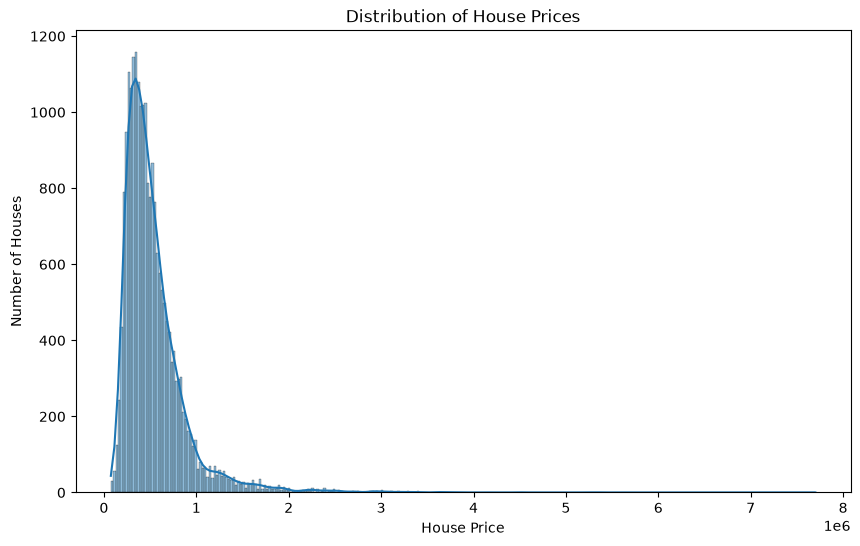

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(df["price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Number of Houses")

plt.show()

### 4.2 House Price vs Living Area

The living area of a house can have an important relationship with its selling price.

The scatter plot below compares the living area of houses with their selling prices.

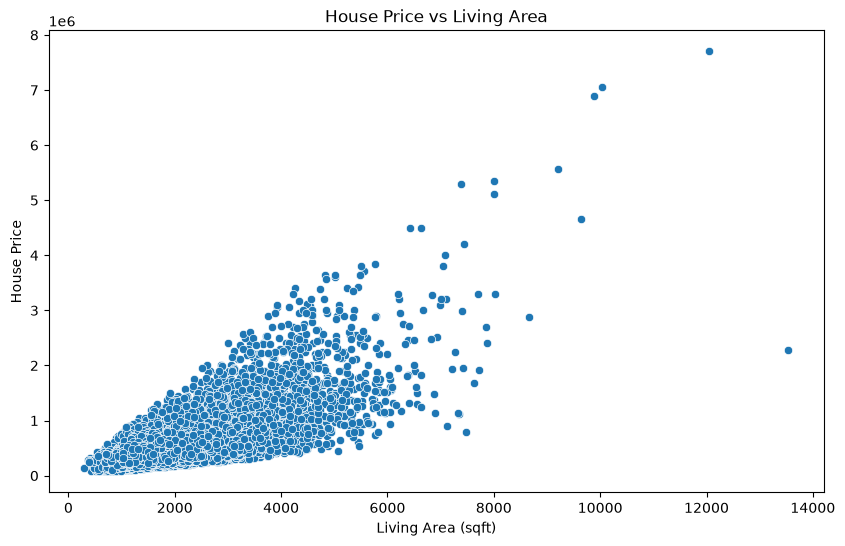

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="sqft_living",
    y="price"
)

plt.title("House Price vs Living Area")
plt.xlabel("Living Area (sqft)")
plt.ylabel("House Price")

plt.show()

### 4.3 House Price vs Number of Bedrooms

This visualization examines whether the number of bedrooms has a relationship with house prices.

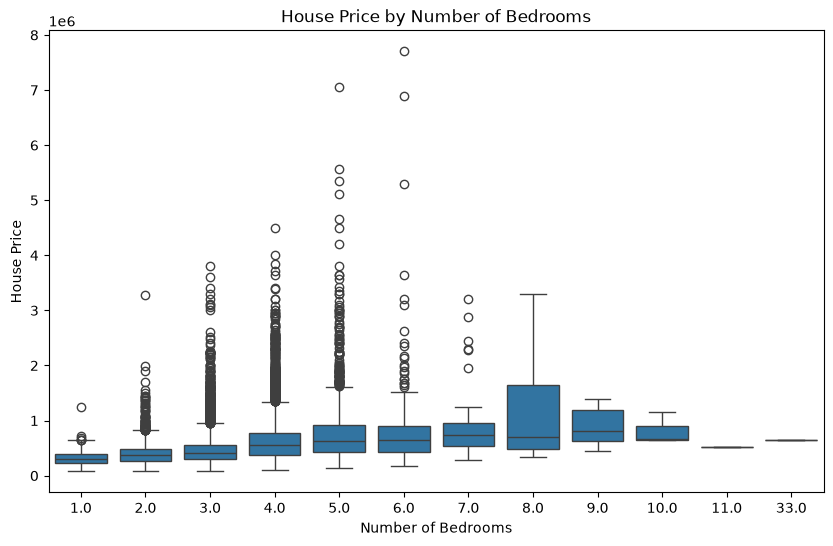

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="bedrooms",
    y="price"
)

plt.title("House Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("House Price")

plt.show()

## 5. Correlation Analysis

Correlation analysis is used to measure the relationship between numerical variables in the dataset.

A correlation value close to +1 indicates a strong positive relationship while a value close to -1 indicates a strong negative relationship.

The correlation matrix will help identify which features have stronger relationships with house prices.

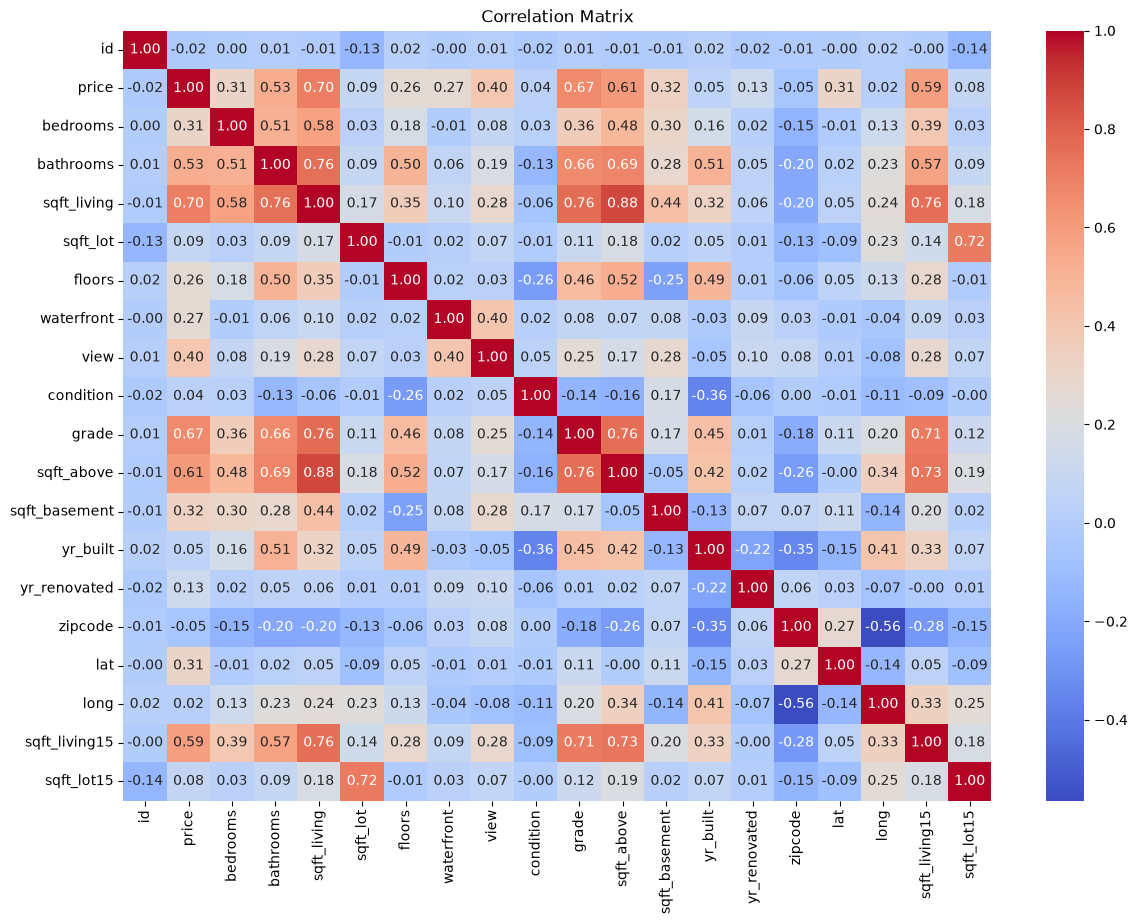

In [20]:
correlation_matrix = df.select_dtypes(include="number").corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

### 6.1 Correlation with House Price

The correlation of each numerical feature with the target variable `price` is calculated.

This helps identify which features have the strongest relationships with house prices.

In [21]:
price_correlation = (
    correlation_matrix["price"]
    .sort_values(ascending=False)
)

print(price_correlation)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525714
view             0.397293
sqft_basement    0.323816
bedrooms         0.308868
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64


## 7. Prepare Data for Machine Learning

Before training a regression model, the dataset must be divided into input features and a target variable.

The `price` column is the target because it represents the selling price of the house.

The remaining relevant columns will be used as input features for predicting the house price.

In [22]:
features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated",
    "zipcode",
    "lat",
    "long",
    "sqft_living15",
    "sqft_lot15"
]

X = df[features]
y = df["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (21613, 18)
Target shape: (21613,)


## 8. Train-Test Split

The dataset is divided into training and testing sets.

The training set is used to teach the regression model while the testing set is used to evaluate how well the model performs on unseen data.

An 80% training and 20% testing split is used.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (17290, 18)
Testing features: (4323, 18)
Training target: (17290,)
Testing target: (4323,)


## 9. Linear Regression Model

Linear Regression is used as the first regression model.

The model attempts to learn the relationship between the selected housing features and the selling price.

The trained model will then be used to predict house prices for the testing dataset.

In [24]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully")

Linear Regression model trained successfully


## 10. Make Predictions

The trained Linear Regression model is used to predict house prices for the testing dataset.

The predicted values will later be compared with the actual house prices to evaluate model performance.

In [25]:
y_pred = linear_model.predict(X_test)

print("Predictions generated successfully")
print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully

First 10 predictions:
[ 461205.8781378   752784.79224342 1237960.95643091 1662455.86794973
  734780.74777593  282683.95421712  831821.78694035  500901.02463293
  384598.23944945  479434.05033765]


## 11. Actual vs Predicted Prices

The actual house prices are compared with the prices predicted by the Linear Regression model.

This provides an initial view of how closely the model's predictions match the real selling prices.

In [26]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,365000.0,4.612059e+05
1,865000.0,7.527848e+05
2,1038000.0,1.237961e+06
3,1490000.0,1.662456e+06
4,711000.0,7.347807e+05
5,211000.0,2.826840e+05
6,790000.0,8.318218e+05
7,680000.0,5.009010e+05
8,384500.0,3.845982e+05
9,605000.0,4.794341e+05


## 12. Model Performance Evaluation

The performance of the Linear Regression model is evaluated using four common regression metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R-squared (R²)

Lower MAE, MSE, and RMSE values indicate smaller prediction errors.

A higher R² score indicates that the model explains more of the variation in house prices.

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("-----------------------------")
print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
-----------------------------
MAE  : 127,510.49
MSE  : 45,196,245,347.08
RMSE : 212,594.09
R²   : 0.7010


## 15. Random Forest Regression

Random Forest Regression is a machine learning algorithm that combines multiple decision trees to make predictions.

It can capture more complex relationships between housing features and prices than a simple Linear Regression model.

A Random Forest model will be trained and its performance will be compared with the Linear Regression model.

In [28]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Random Forest Regression model trained successfully")

Random Forest Regression model trained successfully


## 16. Random Forest Predictions

The trained Random Forest model is used to predict prices for the test dataset.

These predictions will be evaluated using the same metrics used for Linear Regression.

In [29]:
rf_pred = random_forest_model.predict(X_test)

print("Random Forest predictions generated successfully")

Random Forest predictions generated successfully


## 17. Random Forest Model Performance

The Random Forest model is evaluated using MAE, MSE, RMSE, and R².

The results will be compared with the Linear Regression model to determine which model performs better on the test data.

In [30]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("-------------------------")
print(f"MAE  : {rf_mae:,.2f}")
print(f"MSE  : {rf_mse:,.2f}")
print(f"RMSE : {rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
-------------------------
MAE  : 72,875.98
MSE  : 22,178,639,646.44
RMSE : 148,924.95
R²   : 0.8533


## 18. Model Comparison

The performance of the Linear Regression and Random Forest Regression models is compared using the same evaluation metrics.

The model with lower error values and a higher R² score will generally be considered the better-performing model for this dataset.

In [31]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae
    ],
    "MSE": [
        mse,
        rf_mse
    ],
    "RMSE": [
        rmse,
        rf_rmse
    ],
    "R2": [
        r2,
        rf_r2
    ]
})

model_results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,127510.487458,4.519625e+10,212594.085870,0.701037
1,Random Forest,72875.979549,2.217864e+10,148924.946354,0.853293


## 19. Model Performance Comparison

A visual comparison of the R² scores is created to make it easier to identify which model explains more variation in house prices.

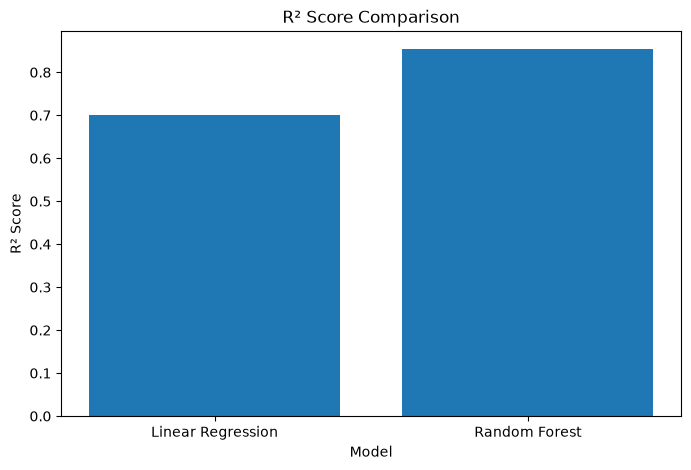

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["R2"]
)

plt.title("R² Score Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

## 20. Feature Importance

Random Forest provides feature importance values that indicate how useful each feature was for making predictions.

This helps us understand which housing characteristics had the greatest influence on the model's predictions.

In [33]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
8,grade,0.314497
2,sqft_living,0.274700
14,lat,0.153156
15,long,0.062878
11,yr_built,0.032829
5,waterfront,0.031873
16,sqft_living15,0.031248
9,sqft_above,0.019742
13,zipcode,0.014800
3,sqft_lot,0.013583


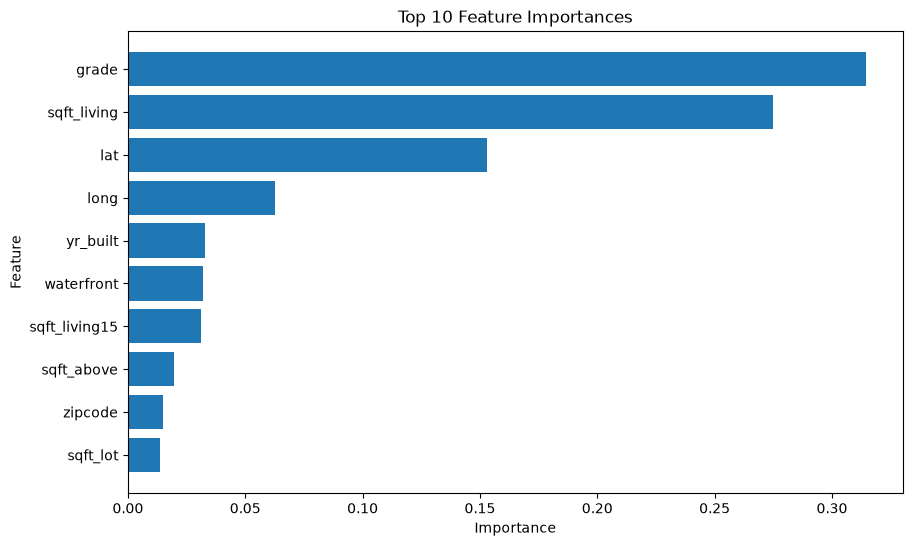

In [34]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

## 21. Select the Best Model

The two regression models are compared using their R² scores.

The model with the highest R² score is selected as the best-performing model for this dataset.

In [35]:
best_model_row = model_results.loc[model_results["R2"].idxmax()]

best_model_name = best_model_row["Model"]

print("Best Model:", best_model_name)
print(f"R² Score: {best_model_row['R2']:.4f}")
print(f"RMSE: {best_model_row['RMSE']:,.2f}")
print(f"MAE: {best_model_row['MAE']:,.2f}")

Best Model: Random Forest
R² Score: 0.8533
RMSE: 148,924.95
MAE: 72,875.98


## 22. Sample House Price Predictions

The selected model is used to generate predictions for a small sample of houses from the testing dataset.

The predicted prices are compared with their actual selling prices.

In [36]:
if best_model_name == "Random Forest":
    best_predictions = rf_pred
else:
    best_predictions = y_pred

sample_predictions = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": best_predictions[:10]
})

sample_predictions["Difference"] = (
    sample_predictions["Actual Price"]
    - sample_predictions["Predicted Price"]
)

sample_predictions

,Actual Price,Predicted Price,Difference
0,365000.0,3.778089e+05,-12808.900000
1,865000.0,8.856355e+05,-20635.470000
2,1038000.0,1.092679e+06,-54678.833333
3,1490000.0,1.907042e+06,-417042.000000
4,711000.0,7.161188e+05,-5118.800000
5,211000.0,2.493714e+05,-38371.360000
6,790000.0,8.612749e+05,-71274.950000
7,680000.0,6.368278e+05,43172.250000
8,384500.0,4.082587e+05,-23758.690000
9,605000.0,5.242833e+05,80716.660000


## 23. Save Model Performance Results

The performance results of both regression models are saved as a CSV file.

This provides a permanent record of the model evaluation and can also be used in the project report.

In [37]:
model_results.to_csv(
    "../results/model_performance.csv",
    index=False
)

print("Model performance saved successfully.")

Model performance saved successfully.


## 24. Save Feature Importance

The feature importance values from the Random Forest model are saved to a CSV file.

This allows us to identify which housing characteristics contributed most to the model's predictions.

In [38]:
feature_importance.to_csv(
    "../results/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


## 25. Final Model Summary

Two regression models were trained and evaluated:

1. Linear Regression
2. Random Forest Regression

The models were evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R².

The model with the highest R² score was selected as the best-performing model.

In [39]:
print("FINAL MODEL SUMMARY")
print("=" * 40)

print("\nModel Performance:")
display(model_results)

print("\nBest Model:")
print(best_model_name)

print(f"\nBest Model R²: {best_model_row['R2']:.4f}")
print(f"Best Model RMSE: {best_model_row['RMSE']:,.2f}")
print(f"Best Model MAE: {best_model_row['MAE']:,.2f}")

FINAL MODEL SUMMARY

Model Performance:


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,127510.487458,4.519625e+10,212594.085870,0.701037
1,Random Forest,72875.979549,2.217864e+10,148924.946354,0.853293



Best Model:
Random Forest

Best Model R²: 0.8533
Best Model RMSE: 148,924.95
Best Model MAE: 72,875.98


## 26. Conclusion

This project developed a machine learning solution for predicting house prices using a real house sales dataset.

The dataset was first explored and cleaned by handling missing values and removing an unnecessary index column. Exploratory Data Analysis was then performed to understand the relationships between housing features and selling prices.

Two regression models were trained:

- Linear Regression
- Random Forest Regression

Both models were evaluated using MAE, MSE, RMSE, and R². The performance results were compared to identify the better-performing model.

The Random Forest model also provided feature importance values which helped identify the housing characteristics that had the greatest influence on the predictions.

Overall, this project demonstrates the complete machine learning workflow from data preparation and exploration to model training, evaluation, comparison, and prediction.